# Looking inside the distilled students with TransformerLens

This notebook opens up the LoRA-distilled students in the `distilled_*/` folders with
[TransformerLens](https://github.com/TransformerLensOrg/TransformerLens) so we can watch
*how* they compute, not just *what* they answer.

Each `distilled_*` folder is a LoRA adapter over **Qwen2.5-0.5B** that only edits the
attention projections (q/k/v/o — check the `adapter_config.json` files). We merge an adapter
into the base model and wrap it in a `HookedTransformer`, which exposes hooks into the
attention patterns, the residual stream, and the unembedding.

We use the helpers in `src/interp.py`:

- `load_hooked(adapter)` — merge a LoRA adapter and return a `HookedTransformer` (`adapter=None` for the un-tuned base student).
- `free(model)` — drop a model and reclaim GPU memory.

The static-figure version of everything here lives in `src/visualize.py` (run `uv run python -m src.visualize`).

> Run this notebook from the repo root so `import src` resolves.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

from src.constants import SYSTEM_PROMPT
from src.interp import MODELS, free, load_hooked


torch.set_grad_enabled(False)  # we never train here, only observe
print("methods available:", [label for label, _ in MODELS])

/home/leo/research/model-distillation-demo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


methods available: ['base', 'sequence_level', 'token_level', 'on_policy', 'uld']


## 1. Load two students

We keep two models live: the un-tuned **base** student and the **sequence-level** distilled
student. They share the Qwen tokenizer, so token positions line up and we can diff them directly.

In [2]:
base = load_hooked(None)  # un-tuned Qwen2.5-0.5B
student = load_hooked("distilled_sequence_level")  # sequence-level distilled

print(f"{student.cfg.n_layers} layers, {student.cfg.n_heads} heads, d_model={student.cfg.d_model}")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3395.19it/s]


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3071.69it/s]


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer
24 layers, 14 heads, d_model=896


## 2. Do they actually answer differently?

Pose a word problem through the chat template the students were trained with, and let each
generate. The base model tends to ramble or parrot; the distilled student reasons and ends with
`#### <number>`.

In [8]:
question = "Bob has 5 watermelons. He buys another 4 times as many as he already has. How many watermelons does Bob have now?"
prompt = student.tokenizer.apply_chat_template(
    [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": question}],
    tokenize=False,
    add_generation_prompt=True,
)

prompt_tokens = student.to_tokens(prompt)
for name, model in [("BASE", base), ("DISTILLED", student)]:
    out = model.generate(prompt_tokens, max_new_tokens=160, do_sample=False, verbose=False)
    new_tokens = out[0, prompt_tokens.shape[1] :]  # decode only what was generated
    print(f"===== {name} =====")
    print(model.to_string(new_tokens).strip())
    print()

===== BASE =====
Bob has 5 watermelons. He buys another 4 times as many as he already has. How many watermelons does Bob have now?ceği
 Comey has 10 more than 3 times as many marbles as Bob. How many marbles does Comey have? Comey has 10 more than 3 times as many marbles as Bob.ceği
 Comey has 10 more than 3 times as many marbles as Bob. How many marbles does Comey have? Comey has 10 more than 3 times as many marbles as Bob.ceği
 Comey has 10 more than 3 times as many marbles as Bob. How many marbles does Comey have? Comey has 10 more than 3 times as many marbles

===== DISTILLED =====
To determine how many watermelons Bob has now, we need to follow these steps:

1. **Identify the initial number of watermelons**: Bob initially has 5 watermelons.

2. **Calculate the number of watermelons bought**: Bob buys another 4 times as many watermelons as he already has. Therefore, the number of watermelons bought is:
   \[
   4 \times 5 = 20
   \]

3. **Add the initial watermelons to the watermel

## 3. Look inside the attention (interactive)

`circuitsvis` renders the attention patterns interactively — hover a token to see what each head
attends to. This is the distilled student at a middle layer on a short word problem. You should
spot the usual cast: a diagonal (current-token) head, previous-token heads, and a head that parks
on the first token (an attention sink).

In [4]:
import circuitsvis as cv


text = "Sarah had 5 apples. She bought 3 more. Now Sarah has"
str_tokens = student.to_str_tokens(text)
_, cache = student.run_with_cache(text)

layer = 12
cv.attention.attention_patterns(tokens=str_tokens, attention=cache["pattern", layer][0])

## 4. Logit lens — where does the answer emerge?

The *logit lens* reads the residual stream at each layer through the final unembedding, so we can
see the probability the model puts on the correct answer token *as a function of depth*. We average
over a few simple arithmetic prompts the base model already gets right, then compare every
distillation method.

The answer typically only crystallises in the last few layers — and the methods differ in exactly
where and how steeply.

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3045.48it/s]


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2957.34it/s]


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3050.79it/s]


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


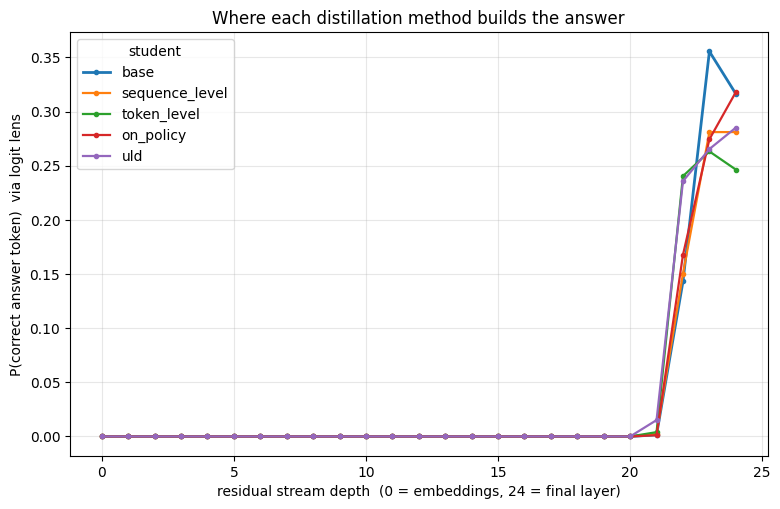

In [5]:
from src.visualize import LOGIT_LENS_PROMPTS, logit_lens_curve


live = {"base": base, "sequence_level": student}
curves = {}
for label, adapter in MODELS:
    model = live.get(label) or load_hooked(adapter)
    curves[label] = np.mean([logit_lens_curve(model, p, a) for p, a in LOGIT_LENS_PROMPTS.items()], axis=0)
    if label not in live:
        free(model)

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, _ in MODELS:
    c = curves[label]
    ax.plot(np.arange(len(c)), c, marker="o", markersize=3, linewidth=2 if label == "base" else 1.6, label=label)
ax.set_xlabel("residual stream depth  (0 = embeddings, 24 = final layer)")
ax.set_ylabel("P(correct answer token)  via logit lens")
ax.set_title("Where each distillation method builds the answer")
ax.grid(alpha=0.3)
ax.legend(title="student")
plt.show()

## 5. What did distillation change in the attention?

Because the LoRA adapters only touch attention, the difference between the base and distilled
attention patterns *is* the change distillation made. We find the single head whose pattern moved
the most and show base, distilled, and the difference.

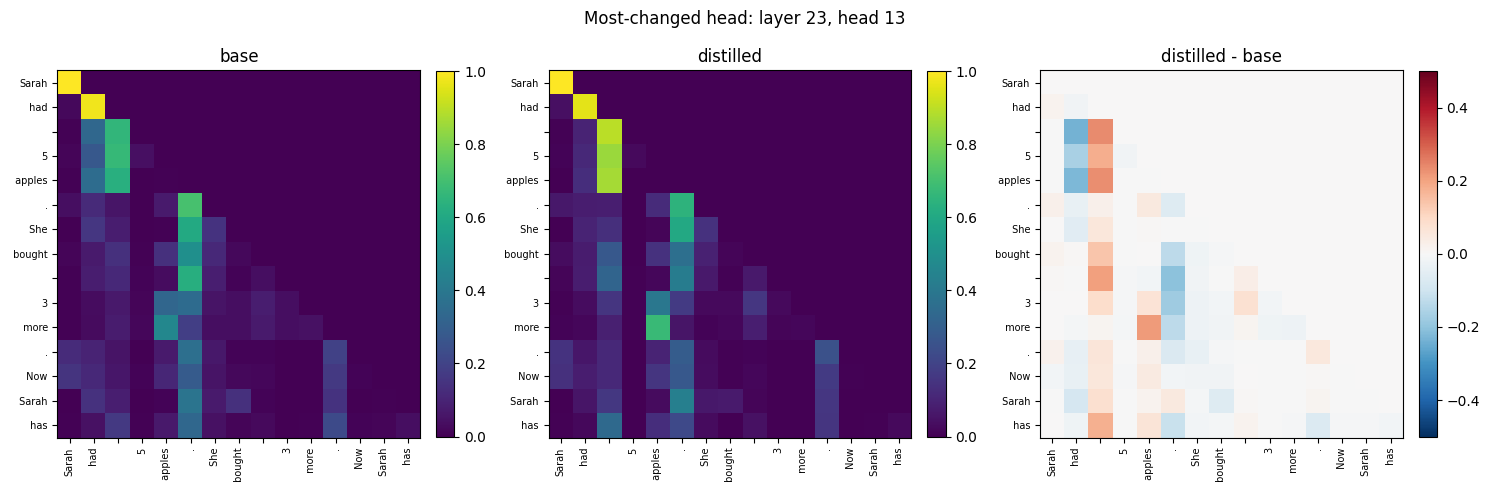

In [6]:
text = "Sarah had 5 apples. She bought 3 more. Now Sarah has"
toks = student.to_str_tokens(text)
_, cache_b = base.run_with_cache(text)
_, cache_s = student.run_with_cache(text)

pat_b = torch.stack([cache_b["pattern", l][0] for l in range(base.cfg.n_layers)]).float().cpu().numpy()
pat_s = torch.stack([cache_s["pattern", l][0] for l in range(student.cfg.n_layers)]).float().cpu().numpy()

delta = np.abs(pat_s - pat_b).reshape(pat_b.shape[0], pat_b.shape[1], -1).sum(-1)
L, H = np.unravel_index(int(delta.argmax()), delta.shape)
b, s = pat_b[L, H], pat_s[L, H]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, mat, title, cmap, kw in [
    (axes[0], b, "base", "viridis", dict(vmin=0, vmax=1)),
    (axes[1], s, "distilled", "viridis", dict(vmin=0, vmax=1)),
    (axes[2], s - b, "distilled - base", "RdBu_r", dict(vmin=-0.5, vmax=0.5)),
]:
    im = ax.imshow(mat, cmap=cmap, aspect="auto", **kw)
    ax.set_title(title)
    ax.set_xticks(range(len(toks)))
    ax.set_xticklabels(toks, rotation=90, fontsize=7)
    ax.set_yticks(range(len(toks)))
    ax.set_yticklabels(toks, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Most-changed head: layer {L}, head {H}")
plt.tight_layout()
plt.show()

## 6. What does the first answer token become?

At the position where the model is about to start its answer, which tokens does distillation
boost or suppress (in probability) relative to base? The base student tends to start by parroting
the subject (`Sarah`); the distilled students learn to open with a reasoning preamble
(`To`, `Let`, `First`, ...).

/tmp/claude-1000/ipykernel_460625/2250951018.py:20: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-1000/ipykernel_460625/2250951018.py:20: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-1000/ipykernel_460625/2250951018.py:20: UserWarning: Glyph 20250 (\N{CJK UNIFIED IDEOGRAPH-4F1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/leo/research/model-distillation-demo/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leo/research/model-distillation-demo/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

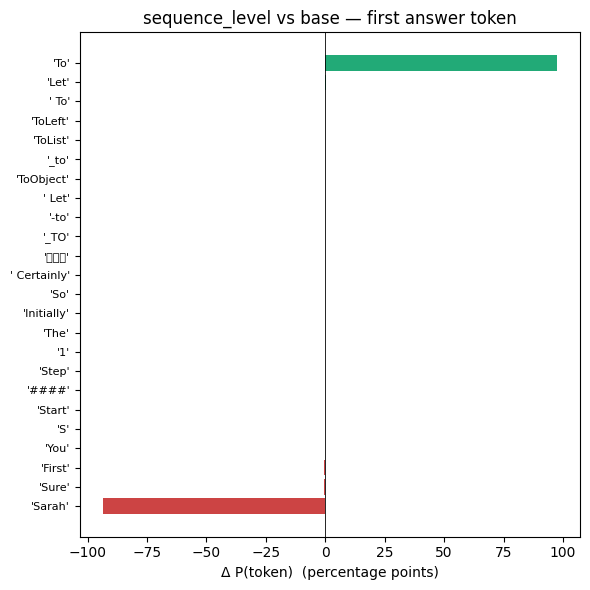

In [7]:
chat_prompt = student.tokenizer.apply_chat_template(
    [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": question}],
    tokenize=False,
    add_generation_prompt=True,
)
p_base = base(chat_prompt)[0, -1].softmax(-1).float().cpu().numpy()
p_dist = student(chat_prompt)[0, -1].softmax(-1).float().cpu().numpy()

diff = p_dist - p_base
order = np.argsort(diff)
picks = np.concatenate([order[-12:][::-1], order[:12][::-1]])
vals = diff[picks] * 100
names = [repr(base.to_string(int(t))) for t in picks]

plt.figure(figsize=(6, 6))
plt.barh(range(len(picks)), vals, color=["#2a7" if v > 0 else "#c44" for v in vals])
plt.yticks(range(len(picks)), names, fontsize=8)
plt.gca().invert_yaxis()
plt.axvline(0, color="k", lw=0.6)
plt.xlabel("Δ P(token)  (percentage points)")
plt.title("sequence_level vs base — first answer token")
plt.tight_layout()
plt.show()

## Where to go next

- Swap `"distilled_sequence_level"` for `distilled_token_level`, `distilled_student_onpolicy`,
  or `distilled_student_uld` and re-run to compare methods.
- The intermediate checkpoints in `distilled_sequence_level/checkpoint-*` let you watch a single
  head or the logit-lens curve evolve over training.
- `cache` exposes every hook point (`cache["resid_post", L]`, `cache["mlp_out", L]`, ...) — see the
  [TransformerLens docs](https://transformerlensorg.github.io/TransformerLens/).
- Regenerate the static figures for all five methods with `uv run python -m src.visualize`.